<a href="https://colab.research.google.com/github/tejas883/Roll_No_32_Machine-Learning-Lab/blob/main/ml_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/selva86/datasets/master/Auto.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
display(df.head())

Dataset loaded successfully!


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [ ]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (392, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 27.7+ KB

Missing Values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64


In [ ]:
df = df.dropna()

df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

df = df.dropna(subset=["horsepower", "mpg"])

print("Dataset after cleaning:")
print(df.shape)

display(df[["horsepower", "mpg"]].head())

Dataset after cleaning:
(392, 9)


,horsepower,mpg
0,130,18.0
1,165,15.0
2,150,18.0
3,150,16.0
4,140,17.0


In [ ]:
X_data = df["horsepower"].values
y = df["mpg"].values

print("Horsepower values:")
print(X_data[:10])

print("\nMPG values:")
print(y[:10])

Horsepower values:
[130 165 150 150 140 198 220 215 225 190]

MPG values:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]


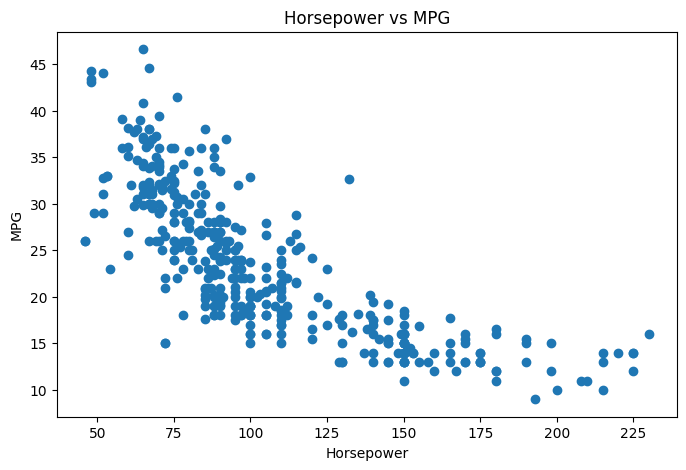

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(X_data, y)

plt.title("Horsepower vs MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")

plt.show()

In [ ]:
X = np.column_stack((np.ones(len(X_data)), X_data))

print("First 5 rows of X:")
print(X[:5])

First 5 rows of X:
[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]


In [ ]:
correlation = np.corrcoef(X_data, y)[0, 1]

print("Correlation between Horsepower and MPG:", correlation)

Correlation between Horsepower and MPG: -0.7784267838977756


In [ ]:
XtX = X.T @ X
XtX_inv = np.linalg.inv(XtX)
Xty = X.T @ y

w = XtX_inv @ Xty

print("OLS Coefficients:")
print("Intercept (w0):", w[0])
print("Slope (w1):", w[1])

OLS Coefficients:
Intercept (w0): 39.93586102117056
Slope (w1): -0.1578447333536543


In [ ]:
y_pred = X @ w

print("First 10 Actual MPG:")
print(y[:10])

print("\nFirst 10 Predicted MPG:")
print(y_pred[:10])

First 10 Actual MPG:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]

First 10 Predicted MPG:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


In [ ]:
residuals = y - y_pred

print("First 10 Residuals:")
print(residuals[:10])

First 10 Residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


In [ ]:
SSE = np.sum((y - y_pred) ** 2)

MSE = np.mean((y - y_pred) ** 2)

SST = np.sum((y - np.mean(y)) ** 2)

R2 = 1 - (SSE / SST)

print("Evaluation Metrics")
print("------------------")
print("SSE:", SSE)
print("MSE:", MSE)
print("R²:", R2)

Evaluation Metrics
------------------
SSE: 9385.915871932419
MSE: 23.943662938603108
R²: 0.6059482578894348


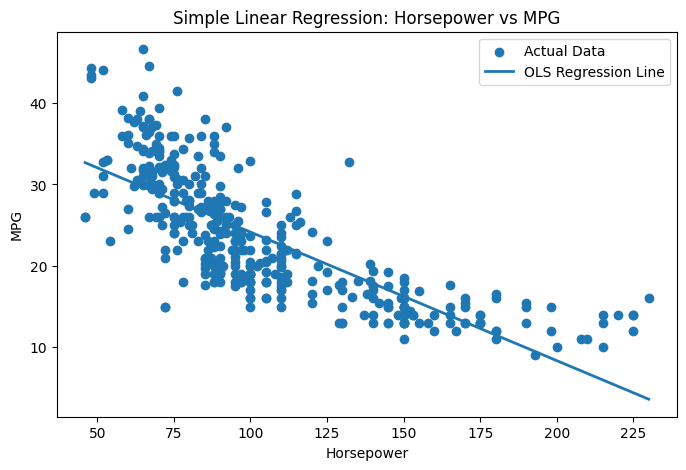

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(X_data, y, label="Actual Data")

sort_index = np.argsort(X_data)

plt.plot(
    X_data[sort_index],
    y_pred[sort_index],
    linewidth=2,
    label="OLS Regression Line"
)

plt.title("Simple Linear Regression: Horsepower vs MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.legend()

plt.show()

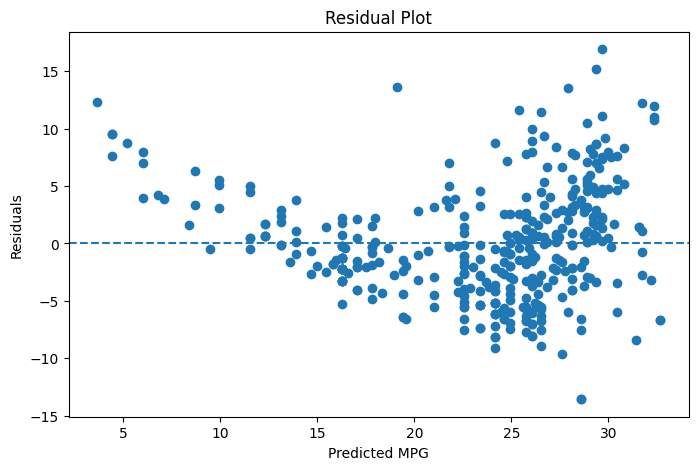

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot")
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")

plt.show()

In [ ]:
print("Regression Equation:")
print(f"MPG = {w[0]:.4f} + ({w[1]:.4f} × Horsepower)")

Regression Equation:
MPG = 39.9359 + (-0.1578 × Horsepower)


In [ ]:
print("Interpretation:")
print(f"1. The correlation between Horsepower and MPG is {correlation:.4f}.")
print(f"2. The slope of the regression line is {w[1]:.4f}.")
print("3. The negative slope indicates that MPG decreases as horsepower increases.")
print(f"4. The R² value is {R2:.4f}.")
print(f"5. The MSE is {MSE:.4f}.")

Interpretation:
1. The correlation between Horsepower and MPG is -0.7784.
2. The slope of the regression line is -0.1578.
3. The negative slope indicates that MPG decreases as horsepower increases.
4. The R² value is 0.6059.
5. The MSE is 23.9437.
